# Transformer architecture

This is a diagram you can find all over the internet, illustrating the transformer architecture. Our job today is to understand the diagram and what all the parts do.

<img src="img/attention_research_1.png" width="500">

In [32]:
import warnings
from itertools import permutations

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, recall_score, precision_score, accuracy_score
from lark import Lark
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore", message="enable_nested_tensor")

<br><br><br><br><br>

## Sample problem

We'll do it in the context of a problem to solve: identifying and then generating valid sentences in a very simple language.

Below is the entire language, expressed as a [BNF grammar](https://en.wikipedia.org/wiki/Backus%E2%80%93Naur_form):

In [2]:
parser = Lark("""
    sentence:    subj    intrans
            |    subj    trans   obj
            | pp subj    intrans
            |    subj    intrans     pp
            |    subj pp intrans
            | pp subj    trans   obj
            |    subj    trans   obj pp
            |    subj pp trans   obj

    subj:      "THE" entity |      "A" entity_cons |      "AN" entity_vowel
    obj:       "THE" entity |      "A" entity_cons |      "AN" entity_vowel
    pp:   prep "THE" place  | prep "A" place_cons  | prep "AN" place_vowel

    entity:       entity_cons | entity_vowel
    place:        place_cons | place_vowel

    entity_cons:  "CAT" | "MOUSE" | "ROBOT"
    entity_vowel: "ALLIGATOR" | "ANT"
    place_cons:   "HOUSE" | "YARD" | "STREET"
    place_vowel:  "AIRPORT" | "OCEAN"

    prep:         "IN" | "UNDER" | "ABOVE"
    intrans:      "SMILES" | "BURPS" | "SLEEPS" | "EXPLODES"
    trans:        "CHASES" | "EATS" | "LOVES" | "HATES"

    %ignore " "
""", start="sentence", parser="lalr", keep_all_tokens=True)

This parser does the task algorithmically (`LALR(1)`). We'll want to train a model to do the same task.

In [3]:
print(parser.parse("THE CAT SMILES").pretty(indent_str="    ").replace("\t", ": "))

sentence
    subj
        THE
        entity
            entity_cons: CAT
    intrans: SMILES


In [4]:
print(parser.parse("THE CAT EATS A MOUSE IN THE STREET").pretty(indent_str="    ").replace("\t", ": "))

sentence
    subj
        THE
        entity
            entity_cons: CAT
    trans: EATS
    obj
        A
        entity_cons: MOUSE
    pp
        prep: IN
        THE
        place
            place_cons: STREET


<br><br><br><br><br>

Data will be given to the model as lists of 8 tokens, using `<BLANK>` as filler at the end.

This `is_valid` function is a drop-in replacement for what we'll want our first model to do.

In [5]:
BLANK = "<BLANK>"

SEQUENCE_LENGTH = 8

def is_valid(tokens):
    # length must be SEQUENCE_LENGTH
    if len(tokens) != SEQUENCE_LENGTH:
        return False

    # all tokens after the first BLANK must be BLANK, allowing for no BLANKs by adding one
    if not all(x == BLANK for x in tokens[(tokens + [BLANK]).index(BLANK):]):
        return False

    try:
        # try to parse the string without BLANKs
        parser.parse(" ".join([x for x in tokens if x != BLANK]))
        return True
    except Exception:
        return False

In [6]:
is_valid(["THE", "CAT", "SMILES", BLANK, BLANK, BLANK, BLANK, BLANK])

True

In [7]:
is_valid(["THE", "CAT", "EATS", "A", "MOUSE", "IN", "THE", "STREET"])

True

In [8]:
is_valid(["THE", "CAT", "EATS", BLANK, BLANK, BLANK, BLANK, BLANK])

False

<br><br><br><br><br>

## Dataset for this sample problem

Random sentences labeled by validity, in which 50% are `ok` and 50% are `bad`.

In [9]:
train_df = pd.read_csv("data/train.csv",    nrows=20000)
valid_df = pd.read_csv("data/validate.csv", nrows=20000)
testy_df = pd.read_csv("data/test.csv",     nrows=20000)

In [10]:
train_df

,t0,t1,t2,t3,t4,t5,t6,t7,label
0,ABOVE,A,STREET,THE,MOUSE,HATES,A,CAT,ok
1,IN,A,HOUSE,AN,ANT,CHASES,A,MOUSE,ok
2,IN,THE,STREET,THE,ANT,CHASES,THE,ANT,ok
3,IN,MOUSE,YARD,A,ROBOT,A,LOVES,A,bad
4,IN,A,YARD,ANT,ALLIGATOR,CHASES,AN,AN,bad
...,...,...,...,...,...,...,...,...,...
19995,A,ROBOT,CHASES,THE,ANT,UNDER,AN,AIRPORT,ok
19996,UNDER,AN,OCEAN,AN,ANT,HATES,THE,ALLIGATOR,ok
19997,AIRPORT,THE,AIRPORT,CAT,ALLIGATOR,LOVES,A,MOUSE,bad
19998,THE,ALLIGATOR,LOVES,AN,ANT,UNDER,A,YARD,ok


<br><br><br><br><br>

One-hot encoding for the 25 tokens:

In [11]:
TOKEN_INDEX = {
    x: i for i, x in enumerate([
        "THE", "A", "AN",
        "CAT", "MOUSE", "ROBOT", "ALLIGATOR", "ANT",
        "HOUSE", "YARD", "STREET", "AIRPORT", "OCEAN",
        "IN", "UNDER", "ABOVE",
        "SMILES", "BURPS", "SLEEPS", "EXPLODES",
        "CHASES", "EATS", "LOVES", "HATES",
        BLANK
    ])
}
VOCABULARY_SIZE = len(TOKEN_INDEX)

def df_to_onehot(df):
    x = torch.zeros((len(df), SEQUENCE_LENGTH, VOCABULARY_SIZE))
    token_columns = [f"t{i}" for i in range(SEQUENCE_LENGTH)]
    indexes = df[token_columns].apply(lambda col: col.map(TOKEN_INDEX).values)
    
    for i, colname in enumerate(token_columns):
        x[torch.arange(len(df)), i, indexes[colname]] = 1

    y = torch.tensor((df["label"] == "ok").astype(int).values, dtype=torch.long)

    return x, y

train_x, train_y = df_to_onehot(train_df)
valid_x, valid_y = df_to_onehot(valid_df)
testy_x, testy_y = df_to_onehot(testy_df)

<br><br><br><br><br>

Look at the first one in the training data:

In [12]:
train_df.iloc[:1]

,t0,t1,t2,t3,t4,t5,t6,t7,label
0,ABOVE,A,STREET,THE,MOUSE,HATES,A,CAT,ok


In [13]:
print(" " + " ".join(f"{x[:4]:4s}" for x in TOKEN_INDEX))
for i in range(SEQUENCE_LENGTH):
    print(str(train_x[0, i].tolist()).replace("0.0", "   "))

 THE  A    AN   CAT  MOUS ROBO ALLI ANT  HOUS YARD STRE AIRP OCEA IN   UNDE ABOV SMIL BURP SLEE EXPL CHAS EATS LOVE HATE <BLA
[   ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    , 1.0,    ,    ,    ,    ,    ,    ,    ,    ,    ]
[   , 1.0,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ]
[   ,    ,    ,    ,    ,    ,    ,    ,    ,    , 1.0,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ]
[1.0,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ]
[   ,    ,    ,    , 1.0,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ]
[   ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    , 1.0,    ]
[   , 1.0,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,   

<br><br><br><br><br>

## Prepare for training

We'll use the same procedure to train all models.

In [14]:
def train(
    model, train_x, train_y, valid_x, valid_y,
    num_epochs=50, batch_size=256, lr=1e-3, weight_decay=5e-4,
):
    "General-purpose training function; works for all models."

    loader = DataLoader(TensorDataset(train_x, train_y), batch_size=batch_size)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.CrossEntropyLoss()
    best_loss, wait = np.inf, 0
    
    train_losses, valid_losses = [], []
    for epoch in tqdm(range(num_epochs)):
        model.train()  # tell PyTorch we're in "training mode"
    
        train_loss = 0
        for batch_x, batch_y in loader:
            # compute the loss for a batch of model predictions and targets
            loss = loss_fn(model(batch_x), batch_y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(batch_x)
        train_loss /= len(train_x)
        train_losses.append(train_loss)
    
        model.eval()  # tell PyTorch we're in "evaluation mode"
    
        with torch.no_grad():  # focus only on values, not derivatives
            valid_loss = loss_fn(model(valid_x), valid_y).item()
        valid_losses.append(valid_loss)

    return train_losses, valid_losses

<br><br><br><br><br>

## Old-fashioned neural network

For each data row, we have 8 tokens, and each token is represented by a 25-dimensional one-hot vector.

For an old-fashioned, fully-connected neural network, just flatten it to a 8×25 = 200-dimensional input vector.

In [15]:
train_flat_x = train_x.reshape(-1, SEQUENCE_LENGTH * VOCABULARY_SIZE)
valid_flat_x = valid_x.reshape(-1, SEQUENCE_LENGTH * VOCABULARY_SIZE)
testy_flat_x = testy_x.reshape(-1, SEQUENCE_LENGTH * VOCABULARY_SIZE)

In [16]:
train_x.shape

torch.Size([20000, 8, 25])

In [17]:
train_flat_x.shape

torch.Size([20000, 200])

<br><br><br><br><br>

The model has a hidden layer of length 128 and then a two-class decision space.

In [19]:
HIDDEN_LAYER = 128

model_mlp = nn.Sequential(
    nn.Linear(SEQUENCE_LENGTH * VOCABULARY_SIZE, HIDDEN_LAYER),
    nn.ReLU(),
    nn.Linear(HIDDEN_LAYER, 2),
)

train_losses, valid_losses = train(model_mlp, train_flat_x, train_y, valid_flat_x, valid_y)

  0%|          | 0/50 [00:00<?, ?it/s]

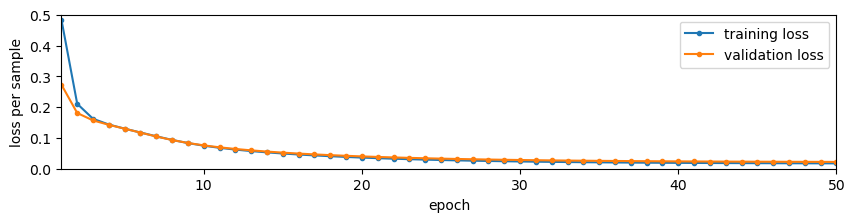

In [20]:
fig, ax = plt.subplots(figsize=(10, 2))

ax.plot(np.arange(1, len(train_losses) + 1), train_losses, marker=".", label="training loss")
ax.plot(np.arange(1, len(valid_losses) + 1), valid_losses, marker=".", label="validation loss")
ax.set_xlabel("epoch")
ax.set_ylabel("loss per sample")
ax.set_xlim(1, len(train_losses))
ax.set_ylim(0, 0.5)
ax.legend()

None

<br><br><br><br><br>

It's a good model.

In [21]:
model_mlp.eval()
with torch.no_grad():
    testy_predictions = model_mlp(testy_flat_x).argmax(dim=1).numpy()

confusion_matrix(testy_y.numpy(), testy_predictions)

array([[ 9842,   105],
       [    0, 10053]])

In [22]:
accuracy_score(testy_y.numpy(), testy_predictions)

0.99475

In [23]:
precision_score(testy_y.numpy(), testy_predictions)

0.9896633195510928

In [24]:
recall_score(testy_y.numpy(), testy_predictions)

1.0

<br><br><br><br><br>

## Now with half a transformer

To decide if a sentence is valid, we only need half a transformer: tokens go into the encoder and then the encoder's output gets passed through a 2-class decision (whatever size the vector is → 2 dimensions).

<img src="img/encoder-only.png" width="500">

In [25]:
class Encoder(nn.Module):
    def __init__(self, position_encoding, d_model=32, nhead=2, num_layers=1, dim_feedforward=128):
        super().__init__()

        # take one-hot encoded inputs to the query-key-value vector size
        self.input_embedding = nn.Linear(VOCABULARY_SIZE, d_model, bias=False)

        # we'll test three types of position encoding: none, learned, and RoPE
        self.position_encoding = position_encoding
        if position_encoding == "learned":
            self.position_embedding = nn.Embedding(SEQUENCE_LENGTH, d_model)

        # here's a prototypical encoder layer
        layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=0, batch_first=True, norm_first=True,
        )
        # now make num_layers of them
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)

        # the two-class decision
        self.decision = nn.Linear(d_model, 2)

    def forward(self, x):
        embedded = self.input_embedding(x)

        if self.position_encoding == "learned":
            embedded += self.position_embedding(torch.arange(x.size(1), device=x.device))
        elif self.position_encoding == "rope":
            embedded = rope_encode(embedded)

        out = self.encoder(embedded)

        return self.decision(out.mean(dim=1))

<br><br><br><br><br>

### No position encoding

Train an encoder with _no_ position encoding.

In [70]:
model_encoder_none = Encoder("none")

train_losses, valid_losses = train(model_encoder_none, train_x, train_y, valid_x, valid_y)

  0%|          | 0/50 [00:00<?, ?it/s]

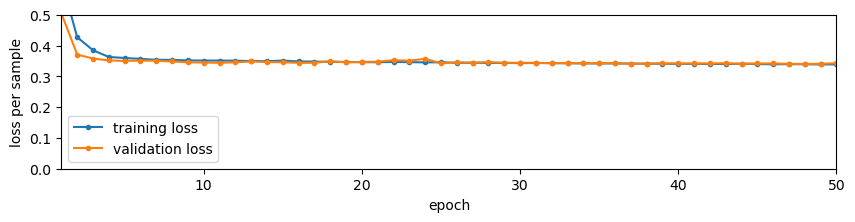

In [71]:
fig, ax = plt.subplots(figsize=(10, 2))

ax.plot(np.arange(1, len(train_losses) + 1), train_losses, marker=".", label="training loss")
ax.plot(np.arange(1, len(valid_losses) + 1), valid_losses, marker=".", label="validation loss")
ax.set_xlabel("epoch")
ax.set_ylabel("loss per sample")
ax.set_xlim(1, len(train_losses))
ax.set_ylim(0, 0.5)
ax.legend()

None

<br><br><br><br><br>

The model quality is poor:

In [72]:
model_encoder_none.eval()
with torch.no_grad():
    testy_predictions = model_encoder_none(testy_x).argmax(dim=1).numpy()

confusion_matrix(testy_y.numpy(), testy_predictions)

array([[7146, 2801],
       [ 128, 9925]])

In [73]:
accuracy_score(testy_y.numpy(), testy_predictions)

0.85355

In [74]:
precision_score(testy_y.numpy(), testy_predictions)

0.7798994185132799

In [75]:
recall_score(testy_y.numpy(), testy_predictions)

0.9872674823435791

<br><br><br><br><br>

But that's because it's trying to validate sentences without knowing how they're ordered.

In [76]:
permuted_sentence = pd.DataFrame(
    permutations(["THE", "CAT", "EATS", "THE", "MOUSE", "IN", "THE", "YARD"]),
    columns=[f"t{i}" for i in range(8)],
)
permuted_sentence["label"] = [is_valid(list(row)) for _, row in permuted_sentence.iterrows()]
permuted_sentence

,t0,t1,t2,t3,t4,t5,t6,t7,label
0,THE,CAT,EATS,THE,MOUSE,IN,THE,YARD,True
1,THE,CAT,EATS,THE,MOUSE,IN,YARD,THE,False
2,THE,CAT,EATS,THE,MOUSE,THE,IN,YARD,False
3,THE,CAT,EATS,THE,MOUSE,THE,YARD,IN,False
4,THE,CAT,EATS,THE,MOUSE,YARD,IN,THE,False
...,...,...,...,...,...,...,...,...,...
40315,YARD,THE,IN,MOUSE,THE,THE,EATS,CAT,False
40316,YARD,THE,IN,MOUSE,THE,CAT,THE,EATS,False
40317,YARD,THE,IN,MOUSE,THE,CAT,EATS,THE,False
40318,YARD,THE,IN,MOUSE,THE,EATS,THE,CAT,False


In [77]:
permuted_sentence_x, permuted_sentence_y = df_to_onehot(permuted_sentence)

permuted_sentence_predictions = model_encoder_none(permuted_sentence_x).detach().numpy()
permuted_sentence_predictions

array([[-0.43259394,  0.7422149 ],
       [-0.43259394,  0.742215  ],
       [-0.43259394,  0.7422149 ],
       ...,
       [-0.43259382,  0.7422148 ],
       [-0.43259376,  0.7422147 ],
       [-0.43259376,  0.74221474]], shape=(40320, 2), dtype=float32)

The model predicts the same 2-dimensional logits for all 40320 permutations.

In [78]:
abs(permuted_sentence_predictions - list(permuted_sentence_predictions[0])).max()

np.float32(3.5762787e-07)

<br><br><br><br><br>

But it does learn how many verbs a sentence ought to have.

In [81]:
parts_of_speech = pd.DataFrame([
    ["THE", "MOUSE", BLANK,      BLANK,      BLANK, BLANK, BLANK, BLANK],
    ["THE", "MOUSE", "SMILES",   BLANK,      BLANK, BLANK, BLANK, BLANK],
    ["THE", "MOUSE", "BURPS",    BLANK,      BLANK, BLANK, BLANK, BLANK],
    ["THE", "MOUSE", "SLEEPS",   BLANK,      BLANK, BLANK, BLANK, BLANK],
    ["THE", "MOUSE", "EXPLODES", BLANK,      BLANK, BLANK, BLANK, BLANK],
    ["THE", "MOUSE", "SMILES",   "SMILES",   BLANK, BLANK, BLANK, BLANK],
    ["THE", "MOUSE", "BURPS",    "BURPS",    BLANK, BLANK, BLANK, BLANK],
    ["THE", "MOUSE", "SLEEPS",   "SLEEPS",   BLANK, BLANK, BLANK, BLANK],
    ["THE", "MOUSE", "EXPLODES", "EXPLODES", BLANK, BLANK, BLANK, BLANK],
], columns=[f"t{i}" for i in range(8)])
parts_of_speech["label"] = [is_valid(list(row)) for _, row in parts_of_speech.iterrows()]
parts_of_speech

,t0,t1,t2,t3,t4,t5,t6,t7,label
0,THE,MOUSE,<BLANK>,<BLANK>,<BLANK>,<BLANK>,<BLANK>,<BLANK>,False
1,THE,MOUSE,SMILES,<BLANK>,<BLANK>,<BLANK>,<BLANK>,<BLANK>,True
2,THE,MOUSE,BURPS,<BLANK>,<BLANK>,<BLANK>,<BLANK>,<BLANK>,True
3,THE,MOUSE,SLEEPS,<BLANK>,<BLANK>,<BLANK>,<BLANK>,<BLANK>,True
4,THE,MOUSE,EXPLODES,<BLANK>,<BLANK>,<BLANK>,<BLANK>,<BLANK>,True
5,THE,MOUSE,SMILES,SMILES,<BLANK>,<BLANK>,<BLANK>,<BLANK>,False
6,THE,MOUSE,BURPS,BURPS,<BLANK>,<BLANK>,<BLANK>,<BLANK>,False
7,THE,MOUSE,SLEEPS,SLEEPS,<BLANK>,<BLANK>,<BLANK>,<BLANK>,False
8,THE,MOUSE,EXPLODES,EXPLODES,<BLANK>,<BLANK>,<BLANK>,<BLANK>,False


In [82]:
parts_of_speech_x, parts_of_speech_y = df_to_onehot(parts_of_speech)

parts_of_speech["probability"] = model_encoder_none(parts_of_speech_x).softmax(-1)[:, 1].detach().numpy() * 100
parts_of_speech

,t0,t1,t2,t3,t4,t5,t6,t7,label,probability
0,THE,MOUSE,<BLANK>,<BLANK>,<BLANK>,<BLANK>,<BLANK>,<BLANK>,False,0.703631
1,THE,MOUSE,SMILES,<BLANK>,<BLANK>,<BLANK>,<BLANK>,<BLANK>,True,97.539688
2,THE,MOUSE,BURPS,<BLANK>,<BLANK>,<BLANK>,<BLANK>,<BLANK>,True,97.921356
3,THE,MOUSE,SLEEPS,<BLANK>,<BLANK>,<BLANK>,<BLANK>,<BLANK>,True,97.810028
4,THE,MOUSE,EXPLODES,<BLANK>,<BLANK>,<BLANK>,<BLANK>,<BLANK>,True,97.255104
5,THE,MOUSE,SMILES,SMILES,<BLANK>,<BLANK>,<BLANK>,<BLANK>,False,0.102497
6,THE,MOUSE,BURPS,BURPS,<BLANK>,<BLANK>,<BLANK>,<BLANK>,False,0.016367
7,THE,MOUSE,SLEEPS,SLEEPS,<BLANK>,<BLANK>,<BLANK>,<BLANK>,False,0.099173
8,THE,MOUSE,EXPLODES,EXPLODES,<BLANK>,<BLANK>,<BLANK>,<BLANK>,False,0.002221


<br><br><br><br><br>

### Learned position encoding